In [2]:
from google.colab import drive
import os

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

print("Drive ready")

Mounted at /content/drive
Drive ready


In [3]:
PROJECT_DIR = "/content/drive/MyDrive/seal_tracking_colab"

DATA_DIR    = f"{PROJECT_DIR}/data"
FRAME_DIR   = f"{DATA_DIR}/frames"

OUTPUT_DIR      = f"{PROJECT_DIR}/outputs"
FIGURE_DIR      = f"{OUTPUT_DIR}/figures"
ATTENTION_DIR   = f"{OUTPUT_DIR}/attention_maps"

from pathlib import Path
Path(FIGURE_DIR).mkdir(parents=True, exist_ok=True)
Path(ATTENTION_DIR).mkdir(parents=True, exist_ok=True)

print("Paths ready")

Paths ready


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from PIL import Image
from pathlib import Path
import torchvision.transforms as transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [5]:
model = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
model = model.to(device)
model.eval()

print("Model loaded on:", device)
print("Number of attention heads:", model.num_heads)

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 386MB/s]


Model loaded on: cuda
Number of attention heads: 6


In [6]:
def extract_attention_maps(image_path, model, image_size, device):

    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Storage for QKV weights
    qkv_storage = []

    def qkv_hook(module, input, output):
        qkv_storage.append(output.detach().cpu())

    # Hook into the QKV linear layer of the last block
    last_block = model.blocks[-1]
    hook = last_block.attn.qkv.register_forward_hook(qkv_hook)

    with torch.no_grad():
        _ = model(image_tensor)

    hook.remove()

    if len(qkv_storage) == 0:
        raise RuntimeError("Hook did not capture QKV output.")

    # --- Recompute attention from QKV ---
    qkv = qkv_storage[0]

    B, N, _ = qkv.shape
    num_heads = model.blocks[-1].attn.num_heads
    head_dim = qkv.shape[-1] // (3 * num_heads)

    # Reshape to separate Q, K, V
    qkv = qkv.reshape(B, N, 3, num_heads, head_dim).permute(2, 0, 3, 1, 4)
    q, k, v = qkv[0], qkv[1], qkv[2]

    # Scaled dot-product attention weights
    scale = head_dim ** -0.5
    attn = (q @ k.transpose(-2, -1)) * scale
    attn = torch.nn.functional.softmax(attn, dim=-1)

    attn = attn.numpy()

    num_patches = N - 1
    grid_size = int(num_patches ** 0.5)

    # CLS token (row 0) → all image patches (cols 1..end)
    cls_attention = attn[0, :, 0, 1:]
    attention_maps = cls_attention.reshape(num_heads, grid_size, grid_size)

    # Normalize each head to [0, 1]
    for h in range(num_heads):
        head_min = attention_maps[h].min()
        head_max = attention_maps[h].max()
        if head_max > head_min:
            attention_maps[h] = (attention_maps[h] - head_min) / (head_max - head_min)

    return image, attention_maps, grid_size

In [7]:
def upsample_attention(attention_map, target_size):
    """
    Upsample a 2D attention map from grid resolution to image resolution.
    Uses bilinear interpolation — smooth, no blocky artifacts.
    """
    upsampled = cv2.resize(
        attention_map,
        (target_size, target_size),
        interpolation=cv2.INTER_LINEAR
    )
    return upsampled


In [8]:
def visualize_all_heads(image, attention_maps, image_size, save_path=None):
    # Plot original image, average attention, and all individual head maps.

    num_heads = attention_maps.shape[0]
    image_resized = image.resize((image_size, image_size))

    # Compute average attention across all heads
    avg_attention = attention_maps.mean(axis=0)
    avg_upsampled = upsample_attention(avg_attention, image_size)

    # Layout: first row = original + average, then one row per head
    n_cols = 2
    n_rows = 1 + (num_heads + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))

    # Row 0: original image and average attention overlay
    axes[0, 0].imshow(image_resized)
    axes[0, 0].set_title("Original Frame", fontsize=13)
    axes[0, 0].axis("off")

    axes[0, 1].imshow(image_resized)
    axes[0, 1].imshow(avg_upsampled, cmap="inferno", alpha=0.6)
    axes[0, 1].set_title("Average Attention (all heads)", fontsize=13)
    axes[0, 1].axis("off")

    # Remaining rows: individual heads
    for h in range(num_heads):
        row = 1 + h // 2
        col = h % 2

        head_upsampled = upsample_attention(attention_maps[h], image_size)

        axes[row, col].imshow(image_resized)
        axes[row, col].imshow(head_upsampled, cmap="inferno", alpha=0.6)
        axes[row, col].set_title(f"Head {h+1}", fontsize=12)
        axes[row, col].axis("off")

    # Hide any unused subplot (if num_heads is odd)
    if num_heads % 2 != 0:
        axes[-1, -1].axis("off")

    plt.suptitle("DINOv2 Self-Attention Maps — CLS Token", fontsize=15, y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

In [9]:
# Load frames from Video 1 (already extracted in previous notebook)
frame_dir_v1 = Path(FRAME_DIR) / "video_01_dense"
frame_paths_v1 = sorted(frame_dir_v1.glob("*.jpg"))

print(f"Found {len(frame_paths_v1)} frames from Video 1")

reference_frame = frame_paths_v1[0]
print("Reference frame:", reference_frame.name)

Found 106 frames from Video 1
Reference frame: frame_0000.jpg


In [10]:
# Extract attention maps at 518x518 — same resolution as your baseline tracking
IMAGE_SIZE = 518

image, attention_maps, grid_size = extract_attention_maps(
    reference_frame, model, IMAGE_SIZE, device
)

print(f"Attention maps shape: {attention_maps.shape}")
print(f"Grid size: {grid_size}")
print(f"Number of heads: {attention_maps.shape[0]}")

Attention maps shape: (6, 37, 37)
Grid size: 37
Number of heads: 6


Saved: /content/drive/MyDrive/seal_tracking_colab/outputs/attention_maps/video1_ref_frame_all_heads_518.png


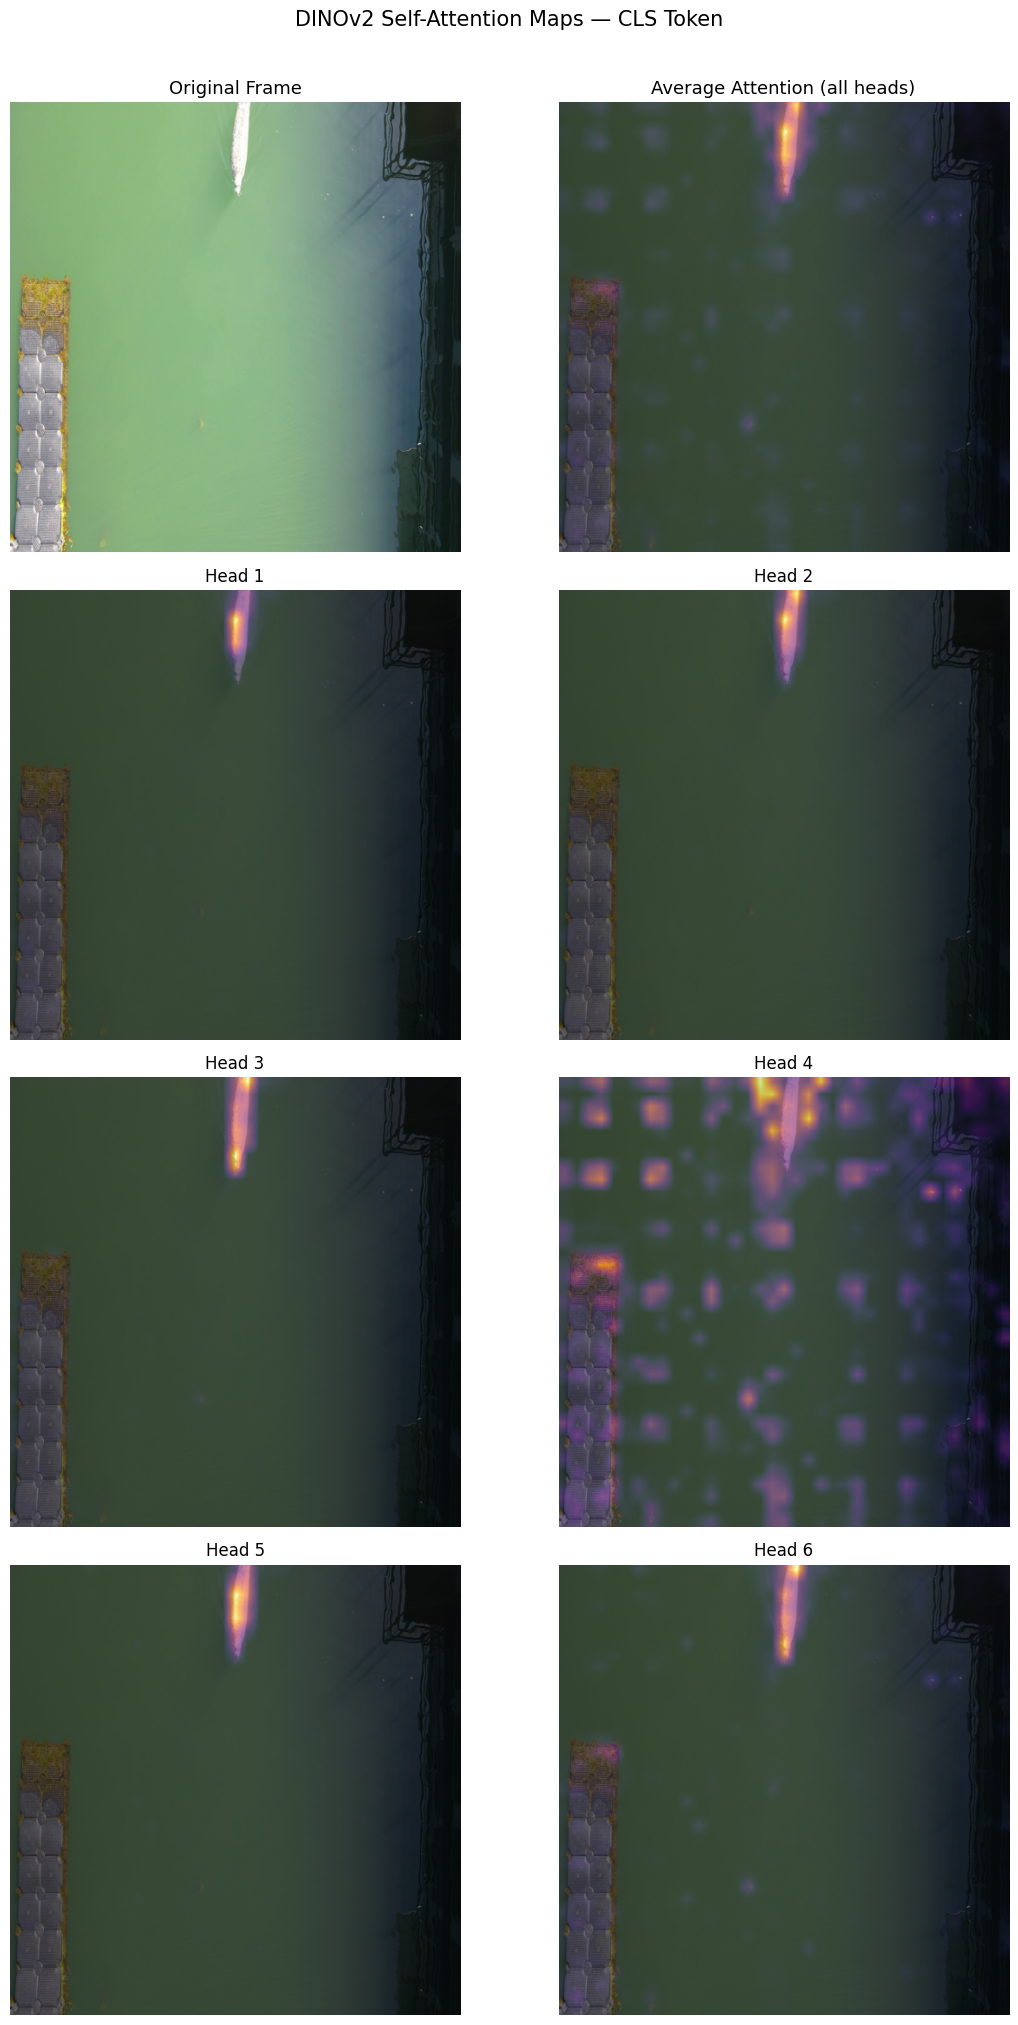

In [11]:
# Visualize all 6 heads + average on the reference frame
save_path = f"{ATTENTION_DIR}/video1_ref_frame_all_heads_518.png"

visualize_all_heads(
    image,
    attention_maps,
    IMAGE_SIZE,
    save_path=save_path
)

Head 3 clearly highlights the seal. Head 4 is noisy and focus on the background.

In [22]:
best_heads = [1, 2, 4]

print("Best heads selected:", best_heads)

Best heads selected: [1, 2, 4]


### Compare 518 vs 728: Does Resolution Improve Attention Quality?

In [23]:
# Extract at 728x728
IMAGE_SIZE_728 = 728

image_728, attention_maps_728, grid_size_728 = extract_attention_maps(
    reference_frame, model, IMAGE_SIZE_728, device
)

print(f"728 attention maps shape: {attention_maps_728.shape}")
print(f"728 grid size: {grid_size_728}")

728 attention maps shape: (6, 52, 52)
728 grid size: 52


In [24]:
def compare_resolution_attention(image, attn_518, attn_728, head_idx=0, save_path=None):

    image_518 = image.resize((518, 518))
    image_728 = image.resize((728, 728))

    avg_518 = upsample_attention(attn_518.mean(axis=0), 518)
    avg_728 = upsample_attention(attn_728.mean(axis=0), 728)

    head_518 = upsample_attention(attn_518[head_idx], 518)
    head_728 = upsample_attention(attn_728[head_idx], 728)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Row 0: average attention
    axes[0, 0].imshow(image_518)
    axes[0, 0].set_title("Original (518)", fontsize=12)
    axes[0, 0].axis("off")

    axes[0, 1].imshow(image_518)
    axes[0, 1].imshow(avg_518, cmap="inferno", alpha=0.6)
    axes[0, 1].set_title("Average Attention — 518×518\n(37×37 grid)", fontsize=12)
    axes[0, 1].axis("off")

    axes[0, 2].imshow(image_728)
    axes[0, 2].imshow(avg_728, cmap="inferno", alpha=0.6)
    axes[0, 2].set_title("Average Attention — 728×728\n(52×52 grid)", fontsize=12)
    axes[0, 2].axis("off")

    # Row 1: individual head comparison
    axes[1, 0].imshow(image_518)
    axes[1, 0].set_title("Original (728 crop shown at 518)", fontsize=12)
    axes[1, 0].axis("off")

    axes[1, 1].imshow(image_518)
    axes[1, 1].imshow(head_518, cmap="inferno", alpha=0.6)
    axes[1, 1].set_title(f"Head {head_idx+1} — 518×518", fontsize=12)
    axes[1, 1].axis("off")

    axes[1, 2].imshow(image_728)
    axes[1, 2].imshow(head_728, cmap="inferno", alpha=0.6)
    axes[1, 2].set_title(f"Head {head_idx+1} — 728×728", fontsize=12)
    axes[1, 2].axis("off")

    plt.suptitle("Attention Map Resolution Comparison: 518 vs 728", fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

Saved: /content/drive/MyDrive/seal_tracking_colab/outputs/attention_maps/video1_resolution_comparison_518_vs_728.png


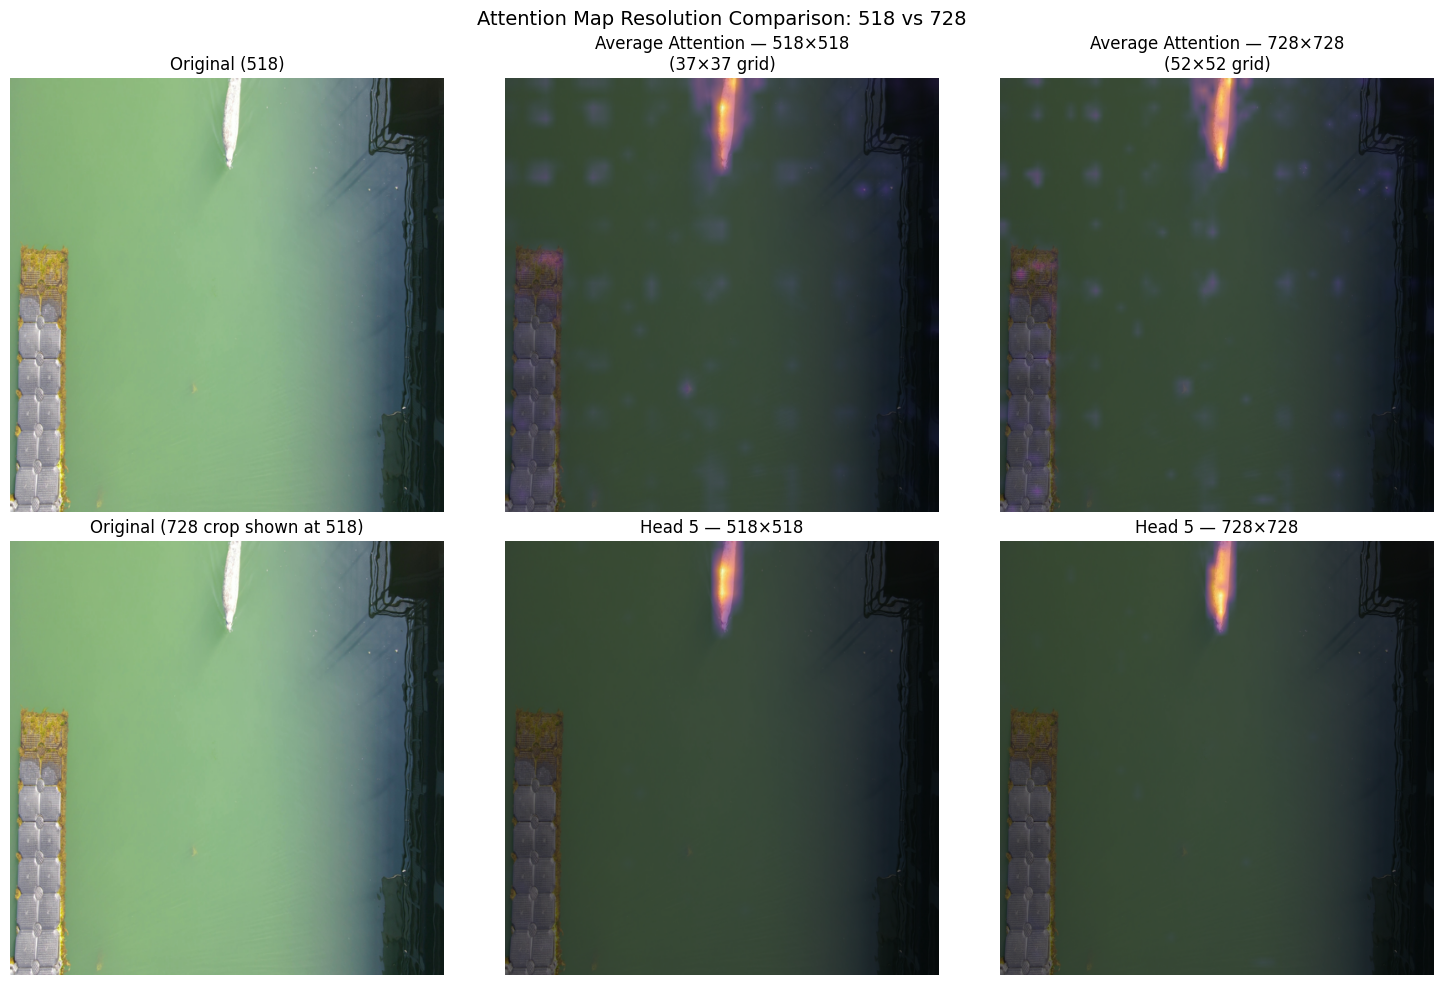

In [30]:
# Run the comparison — update head_idx to your best head
compare_resolution_attention(
    image,
    attention_maps,
    attention_maps_728,
    head_idx=best_heads[2],      # use your best head
    save_path=f"{ATTENTION_DIR}/video1_resolution_comparison_518_vs_728.png"
)

* At 518×518 Head 3 provides the clearest full-body seal highlighting.
* At 728×728 Head 5 provides the clearest coverage, focusing on the entire body rather than just the front.
* Average attention across heads is consistent between resolutions — individual head behavior shifts with resolution.
* This suggests resolution affects which features each head prioritizes, not just sharpness.





### Multi-Frame Consistency

In [31]:
def process_frame_attention(frame_path, model, image_size, device):
    """
    Extract attention maps for a single frame and return the average
    attention map upsampled to image_size.
    """
    image, attention_maps, grid_size = extract_attention_maps(
        frame_path, model, image_size, device
    )
    avg_attention = attention_maps.mean(axis=0)
    avg_upsampled = upsample_attention(avg_attention, image_size)
    return image, avg_upsampled, attention_maps

In [32]:
# Sample frames evenly across the video
sample_interval = 8
sampled_frames = frame_paths_v1[::sample_interval]

print(f"Total frames available: {len(frame_paths_v1)}")
print(f"Frames to process: {len(sampled_frames)}")

Total frames available: 106
Frames to process: 14


In [33]:
# Process each sampled frame - one forward pass per frame
multi_frame_attention = []

for i, frame_path in enumerate(sampled_frames):
    image, avg_attn, all_heads = process_frame_attention(
        frame_path, model, IMAGE_SIZE, device
    )
    multi_frame_attention.append({
        "frame_path": frame_path,
        "image": image,
        "avg_attention": avg_attn,
        "all_heads": all_heads
    })
    if (i + 1) % 5 == 0:
        print(f"Processed {i+1}/{len(sampled_frames)} frames")

print(f"Done. Processed {len(multi_frame_attention)} frames.")

Processed 5/14 frames
Processed 10/14 frames
Done. Processed 14 frames.


In [37]:
# Visualize multi-frame attention consistency

n_frames = len(multi_frame_attention)
fig, axes = plt.subplots(n_frames, 2, figsize=(10, 4 * n_frames))

# Handle edge case where only 1 frame
if n_frames == 1:
    axes = [axes]

for i, result in enumerate(multi_frame_attention):
    img = result["image"].resize((IMAGE_SIZE, IMAGE_SIZE))
    attn = result["avg_attention"]

    axes[i][0].imshow(img)
    axes[i][0].set_title(result["frame_path"].name, fontsize=9)
    axes[i][0].axis("off")

    axes[i][1].imshow(img)
    axes[i][1].imshow(attn, cmap="inferno", alpha=0.55)
    axes[i][1].set_title("Avg Attention", fontsize=9)
    axes[i][1].axis("off")

plt.suptitle("Video 1 — DINOv2 Attention Consistency Across Frames", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(
    f"{ATTENTION_DIR}/video1_multiframe_attention_consistency.png",
    dpi=120,
    bbox_inches="tight"
)
plt.show()
print("Saved multi-frame consistency figure.")

Output hidden; open in https://colab.research.google.com to view.

* Attention consistently follows the seal across all frames where it is visible.
* When the seal exits the frame, attention shifts to the next most salient object rather than diffusing across background water.
* This object was never highlighted while the seal was present — suggesting DINOv2 has a strong preference hierarchy for visually coherent objects.
* DINOv2 representations do consistently highlight the seal without any manual guidance

### Attention on video 3 (Multi-seal)

In [35]:
# Load Video 3 frames
frame_dir_v3 = Path(FRAME_DIR) / "video_03_dense"
frame_paths_v3 = sorted(frame_dir_v3.glob("*.jpg"))

print(f"Found {len(frame_paths_v3)} frames from Video 3")

Found 83 frames from Video 3


In [38]:
# Sample a few frames from Video 3
sample_v3 = frame_paths_v3[::10][:6]   # up to 6 frames

fig, axes = plt.subplots(len(sample_v3), 2, figsize=(10, 4 * len(sample_v3)))

if len(sample_v3) == 1:
    axes = [axes]

for i, frame_path in enumerate(sample_v3):
    image, avg_attn, _ = process_frame_attention(
        frame_path, model, IMAGE_SIZE, device
    )
    img = image.resize((IMAGE_SIZE, IMAGE_SIZE))

    axes[i][0].imshow(img)
    axes[i][0].set_title(frame_path.name, fontsize=9)
    axes[i][0].axis("off")

    axes[i][1].imshow(img)
    axes[i][1].imshow(avg_attn, cmap="inferno", alpha=0.55)
    axes[i][1].set_title("Avg Attention — Multi-Seal", fontsize=9)
    axes[i][1].axis("off")

plt.suptitle("Video 3 — DINOv2 Attention on Multi-Seal Frames", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(
    f"{ATTENTION_DIR}/video3_multiseal_attention.png",
    dpi=120,
    bbox_inches="tight"
)
plt.show()
print("Saved Video 3 attention figure.")

Output hidden; open in https://colab.research.google.com to view.

* Single seal, clear water → attention is sharp and consistent across all frames.
* Single seal, leaving frame → attention transfers to next most salient object.
* Multiple seals → all seals captured simultaneously with no manual guidance.
* Seals underwater/partially submerged → attention weakens proportionally to visibility.

### **Attention-based localization vs Similarity-based tracking**

* Attention maps require no manual seed points and work on any frame instantly with zero human input, while similarity-based tracking needs manually selected reference patches from the specific video.
* However, attention maps treat every frame independently, they have no temporal memory of where the seal was previously. Similarity-based tracking uses the previous frame's location to constrain the search, making it more stable over time.
* For multiple seals, attention highlights all seals simultaneously but cannot assign or maintain separate identities. Similarity-based tracking at least
attempts to distinguish and track individual seals across frames.
* Attention maps also cannot target specific body parts, they show what the model finds globally interesting. Similarity-based tracking can be directed at a specific region (e.g. a flipper) by choosing appropriate seed points.